=== Coverage ===
Total rows:            116,110
SkillUri matched:      116,110 (100.0%)
esco_uri matched:      115,773 (99.7%)
Unique jobs:           2,969
Unique courses:        1,477
Unique skills:         3,079

=== Jobs with lowest SkillUri match rate ===
job
3D animator                               1.0
overhead line worker                      1.0
oxy fuel burning machine operator         1.0
packaging and filling machine operator    1.0
packaging production manager              1.0
packing machinery engineer                1.0
paint mixer                               1.0
palaeontologist                           1.0
palliative care social worker             1.0
paper bag machine operator                1.0


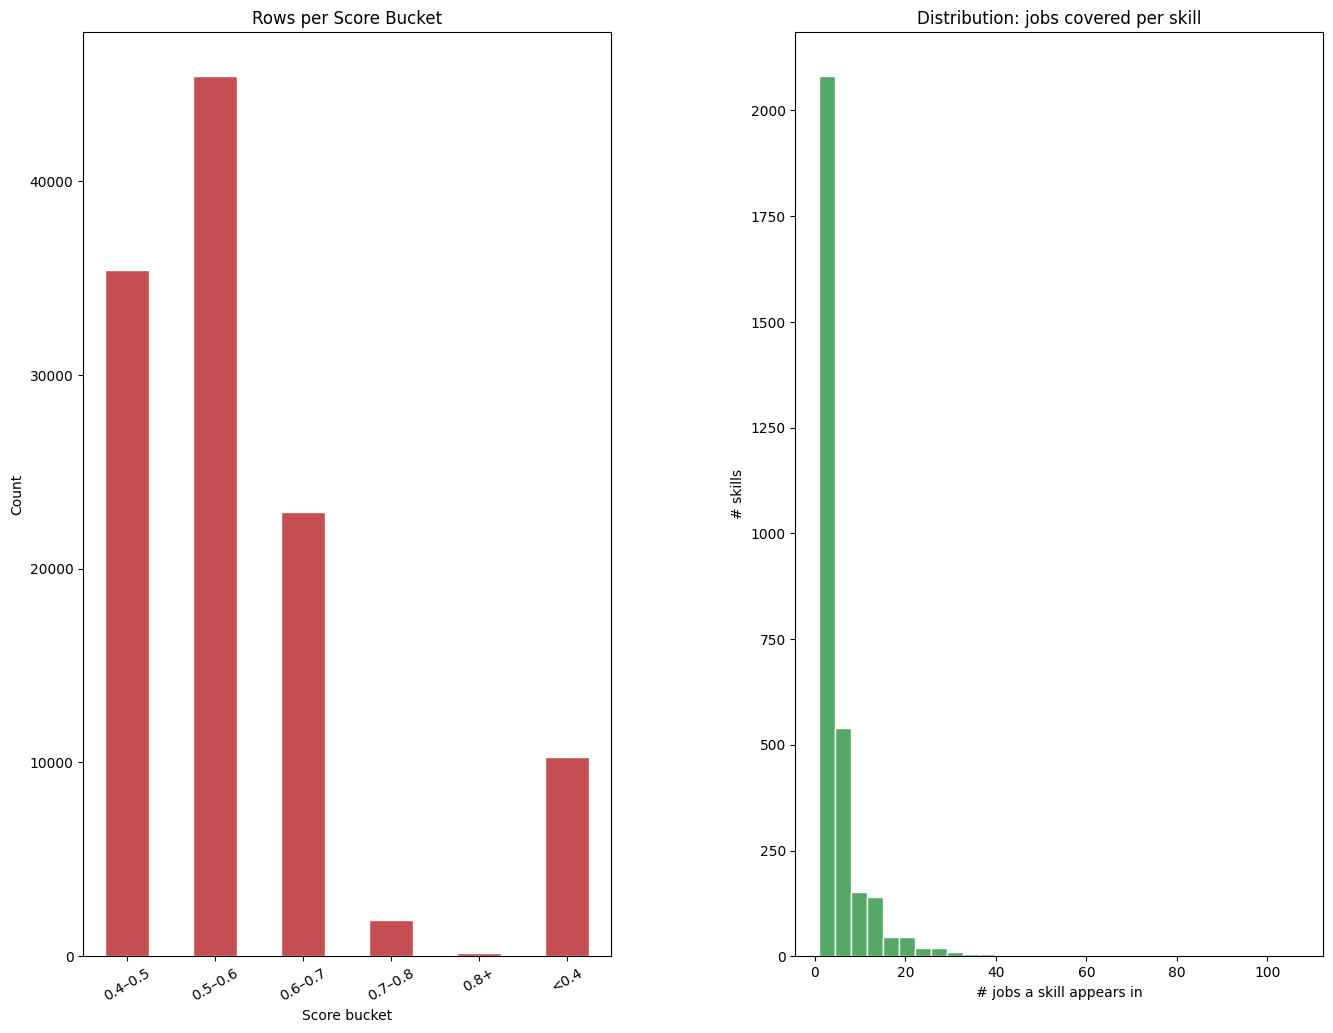

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

df_result = pd.read_excel("job_course_mapping.xlsx", sheet_name="Job_Course_Mapping", dtype=str, keep_default_na=False)
# Force everything out of StringDtype into plain object
df_result = df_result.astype(object)
df_result['score'] = pd.to_numeric(df_result['score'], errors='coerce')

# --- Coverage stats ---
total = len(df_result)
matched_skill = sum(1 for x in df_result['SkillUri'] if x and str(x) not in ('', '<NA>', 'nan', 'None'))
matched_esco  = sum(1 for x in df_result['esco_uri'] if x and str(x) not in ('', '<NA>', 'nan', 'None'))
unique_jobs = df_result['job'].nunique()
unique_courses = df_result['course'].nunique()
unique_skills = df_result['via_skill'].nunique()

print("=== Coverage ===")
print(f"Total rows:            {total:,}")
print(f"SkillUri matched:      {matched_skill:,} ({matched_skill/total:.1%})")
print(f"esco_uri matched:      {matched_esco:,} ({matched_esco/total:.1%})")
print(f"Unique jobs:           {unique_jobs:,}")
print(f"Unique courses:        {unique_courses:,}")
print(f"Unique skills:         {unique_skills:,}")

# --- Score distribution by match status ---
df_result['matched'] = [bool(x and str(x) not in ('', '<NA>', 'nan', 'None')) for x in df_result['SkillUri']]

# --- Per-job match rate ---
job_match = (
    df_result.groupby('job')['matched']
    .mean()
    .sort_values()
)

# --- Score buckets ---
bins = [0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
labels = ['<0.4', '0.4–0.5', '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8+']

def score_to_bucket(s):
    try:
        s = float(s)
        if s < 0.4: return '<0.4'
        elif s < 0.5: return '0.4–0.5'
        elif s < 0.6: return '0.5–0.6'
        elif s < 0.7: return '0.6–0.7'
        elif s < 0.8: return '0.7–0.8'
        else: return '0.8+'
    except: return None

df_result['score_bucket'] = df_result['score'].apply(score_to_bucket)

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.4, wspace=0.35)


ax4 = fig.add_subplot(gs[0, 1])
jobs_per_skill = df_result.groupby('via_skill')['job'].nunique()
ax4.hist(jobs_per_skill, bins=30, color='#55A868', edgecolor='white')
ax4.set_title('Distribution: jobs covered per skill')
ax4.set_xlabel('# jobs a skill appears in')
ax4.set_ylabel('# skills')


ax6 = fig.add_subplot(gs[0, 0])
df_result.groupby('score_bucket', observed=True)['score'].count().plot(
    kind='bar', ax=ax6, color='#C44E52', edgecolor='white'
)
ax6.set_title('Rows per Score Bucket')
ax6.set_xlabel('Score bucket')
ax6.set_ylabel('Count')
ax6.tick_params(axis='x', rotation=30)


print("\n=== Jobs with lowest SkillUri match rate ===")
print(job_match.head(10).to_string())

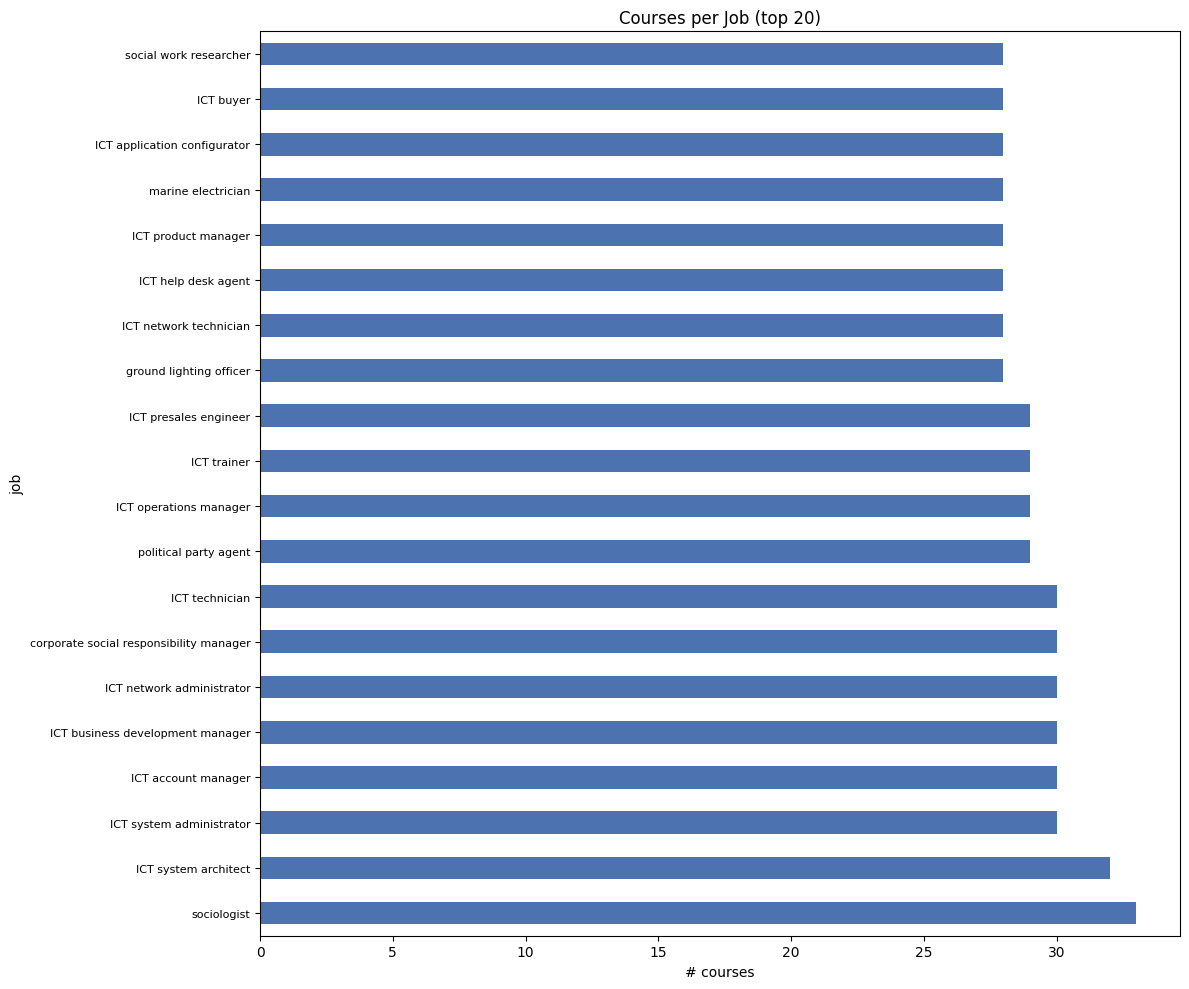

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

df_result.groupby('job')['course'].nunique().sort_values(ascending=False).head(20).plot(
    kind='barh', ax=ax, color='#4C72B0'
)
ax.set_title('Courses per Job (top 20)')
ax.set_xlabel('# courses')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()